This notebook tries to address the issue where we get different mismatch results from different waveform generation methods. The reason is discovered to be that the different methods of simulating _simple lensing_ give different waveforms!

# Module imports

In [1]:
from pathlib import Path
import jax.numpy as np
from jax.lax import broadcast_in_dim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MRSUN_SI, MTSUN_SI, uGpc, DAY_TO_SEC
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal, GeneralLensedGWSignal
import gwfast.network as network
from gwfast.lensing_utils import (
    get_agn_lensed_parameters,
    get_agn_lens_angles,
    PML_time_delay_magnification,
    compute_lensed_angles_approx,
    dLGridGlob, zGridGlob, einstein_angle
    )

from pycbc.filter import match
from pycbc.types.frequencyseries import FrequencySeries

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

/users/hin-wai.leong/src/AGN-gwfast/gwfast/waveforms.py:35: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


# Function definitions

## Lensing related

In [2]:
def PML_simple_lens_parameters(parameters):
    output_params = parameters.copy()
    luminosity_distance = output_params.pop("dL")

    theta_E, beta, lens_mass_src = get_agn_lens_angles(
        output_params['M_lz'], output_params['R_orbit'], 
        output_params['src_pos'], luminosity_distance
    )
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)

    output_params['delta_time'] = time_delay * lens_mass_src * MTSUN_SI / DAY_TO_SEC  # Days (tcoal)
    output_params['dL_1'] = luminosity_distance / np.sqrt(np.abs(mag_1))
    output_params['dL_2'] = luminosity_distance / np.sqrt(np.abs(mag_2))
    output_params['delta_iota']    = np.zeros_like(mag_1)  # No change in iota
    output_params['delta_phase']   = np.zeros_like(mag_1)  # No change in phi
    output_params['delta_psi']     = np.zeros_like(mag_1)  # No change in psi
    output_params['relative_mass'] = np.ones_like(mag_1)  # No change in mass
    return output_params

In [ ]:
# Normal lensing (first order effects) definition
# Yes, this needs to be simplified...
def normal_lens(FD_strain, events, freqs, separate=False):
    r_orbit = events['R_orbit']
    lens_mass = events['M_lz']
    luminosity_distance = events["dL"]
    y_src = events["src_pos"]
    d_LS = r_orbit * np.sqrt(1 - y_src**2)  # R_Sch
    _y_src = y_src * r_orbit  # R_Sch

    # Schwarschild radius
    # A small, but necessary assumption, that the lens is at dL
    z = np.interp(luminosity_distance, dLGridGlob, zGridGlob)
    lens_mass_src = lens_mass / (1 + z)
    R_Sch = 2 * lens_mass_src * MRSUN_SI  # m
    delta = R_Sch / uGpc

    beta = _y_src / luminosity_distance * delta  # Radian
    ang_D_S = luminosity_distance

    ang_D_L = ang_D_S / (1 + d_LS * delta)  # Gpc
    theta_E = einstein_angle(lens_mass_src, ang_D_L, ang_D_S)  # Radian
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
    time_delay *= lens_mass_src * MTSUN_SI  
    time_delay_phase_shift = np.exp(2j * np.pi * freqs * time_delay)

    image_1 = mag_1 * FD_strain
    image_2 = mag_2 * FD_strain * time_delay_phase_shift
    if separate:
        return image_1, image_2
    else:
        return image_1 + image_2

In [4]:
def get_agn_lensed_params(unlensed_parameters, partial='full'):
    plus_image_params = unlensed_parameters.copy()
    minus_image_params = unlensed_parameters.copy()

    lensed_params = compute_lensed_angles_approx(unlensed_parameters)

    # Environemental effects (orbit-induced redshift and gravitational redshift) can be modeled as
    # changes in effective chirp mass and effective luminosity distance
    # https://arxiv.org/abs/2310.16025 Eqs. 4&5
    plus_redshift_factor = (1 + lensed_params['z_rel_p']) * (1 + lensed_params['z_grav'])
    minus_redshift_factor = (1 + lensed_params['z_rel_m']) * (1 + lensed_params['z_grav'])

    plus_image_params['dL'] /= lensed_params['sqrt_mu_p']
    plus_image_params['dL'] *= (1 + lensed_params['z_rel_p']) * plus_redshift_factor
    minus_image_params['dL'] /= lensed_params['sqrt_mu_m']
    minus_image_params['dL'] *= (1 + lensed_params['z_rel_m']) * minus_redshift_factor
    minus_image_params['tcoal'] += lensed_params['delta_time'] / DAY_TO_SEC  # days
    if partial == 'full':
        plus_image_params['iota'] = lensed_params['iota_p']
        plus_image_params['phase'] = lensed_params['phase_p']
        plus_image_params['Mc'] *= plus_redshift_factor
        minus_image_params['iota'] = lensed_params['iota_m']
        minus_image_params['phase'] = lensed_params['phase_m']
        minus_image_params['Mc'] *= minus_redshift_factor
    elif partial == 'no doppler': # only angular changes
        plus_image_params['iota'] = lensed_params['iota_p']
        plus_image_params['phase'] = lensed_params['phase_p']
        minus_image_params['iota'] = lensed_params['iota_m']
        minus_image_params['phase'] = lensed_params['phase_m']
    elif partial == 'no angular': # only effective mass changes
        plus_image_params['Mc'] *= plus_redshift_factor
        minus_image_params['Mc'] *= minus_redshift_factor
    elif partial == 'no agn':
        pass

    return plus_image_params, minus_image_params

## `convert_y_to_src_pos`

In [5]:
def convert_y_to_src_pos(y, R_orbit, rs=1):
    # Convert source position from units of Einstein radius to units of R_orbit
    # Returns a 2D grid of src_pos with shape (len(y), len(R_orbit))
    Dls_min = (np.sqrt(np.square(R_orbit) + np.power(y, 4)) - np.square(y)) * rs # for rs=1, this is in units of R_S
    theta_E = np.sqrt(2 * Dls_min) # Einstein radius in units of R_S
    src_pos = np.outer(y, theta_E / R_orbit)
    return src_pos

## Alternative mismatch ($\overline{MM}$) (no maximizing over phase)

In [76]:
def inner_product(frequencies, h1, h2, psd):
    integrand = np.conj(h1) * h2 / psd
    return 4 * np.real(np.trapezoid(integrand, frequencies, axis=0))

def mismatch_alt(frequencies, h1, h2, psd):
    # Ranges from 0 to 1
    return inner_product(frequencies, h1-h2, h1-h2, psd) / (2 * (inner_product(frequencies, h1, h1, psd) + inner_product(frequencies, h2, h2, psd)))

# def mismatch(frequencies, h1, h2, psd):
#     # Ranges from 0 to 2
#     return 1 - inner_product(frequencies, h1, h2, psd) / np.sqrt(inner_product(frequencies, h1, h1, psd) * inner_product(frequencies, h2, h2, psd))

# Detector setup

In [6]:
# Set up detector
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')

wf_model = waveforms.IMRPhenomD()

L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
L1_Lensed = GeneralLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
L1_BBH = BasicGWSignal(wf_model=wf_model, detector=L1, fmin=10)

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


# Parameter injection

In [7]:
# Define event parameters
n = 200
shape = n
events = {
    'Mc': 50, 'eta': 0.1, 'iota': 0.99*np.pi/2, 'phase': 2,
    'chi1z': 0.3, 'chi2z': 0.5, 'tcoal': 0,
    'R_orbit': 100, 'M_lz': 1e4, 'src_pos': 0.2,
    'dL': 1, 'psi': 4, 'theta': 1.87, 'phi': 2.66,
}
events = {key: np.full(shape, val).astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(10, 1e4, n)
params = events.copy()
params['R_orbit'] = R_orbit_array

## Prepare grid

In [87]:
# Waveform metadata
sampling_frequency = 2048.  # Hz
duration = 8.  # s
f_min = 10.
f_max = sampling_frequency / 2

# This procedure to create coupled time and freq arrays is borrowed from Bilby
N_samples = int(np.round(duration * sampling_frequency))
N_freq_bins = int(np.round(N_samples / 2) + 1)
freq_array = np.linspace(0, sampling_frequency / 2, N_freq_bins)
time_array = np.linspace(0, duration - 1 / sampling_frequency, N_samples)

freq_mask = (freq_array >= f_min) & (freq_array <= f_max)
masked_freq_arr = freq_array[freq_mask]
freq_grid = broadcast_in_dim(freq_array, (N_freq_bins, shape), (0,))
masked_freq_grid = broadcast_in_dim(masked_freq_arr, (masked_freq_arr.size, shape), (0,))

psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = broadcast_in_dim(psd_interp, (N_freq_bins, shape), (0,))

cplx_zeros = np.zeros((freq_array.size, shape), dtype=np.complex128)

FD_generic_AGN_strain = cplx_zeros
FD_generic_simple_strain = cplx_zeros

FD_AGN_strain = cplx_zeros
FD_BBH_strain = cplx_zeros
FD_no_AGN_strain_plus = cplx_zeros
FD_no_AGN_strain_minus = cplx_zeros

## Generate waveform

### With the generic lensing model (Samson)

In [88]:
general_lensed_params = L1_AGN.convert_to_general_lensed_parameters(params)
simple_lensed_params = PML_simple_lens_parameters(params)

FD_generic_AGN_strain = FD_generic_AGN_strain.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_grid, general_lensed_params))
FD_generic_simple_strain = FD_generic_simple_strain.at[freq_mask].set(L1_Lensed.GWstrain(masked_freq_grid, simple_lensed_params))

### With the AGN and BBH models (Ryan) (2 methods)

In [94]:
FD_AGN_strain = FD_AGN_strain.at[freq_mask].set(L1_AGN.GWstrain(masked_freq_grid, params))
# Two methods to generate no-AGN-lensed waveforms
# 1. Use the BBH model, superpose with normal_lens function
FD_BBH_strain = FD_BBH_strain.at[freq_mask].set(L1_BBH.GWstrain(masked_freq_grid, params))
FD_BBH_images_strain = normal_lens(FD_BBH_strain, params, freq_grid)
# 2. Use the BBH model and modified get_agn_lensed_params (with environmental effects turned off)
FD_no_AGN_params_plus,  FD_no_AGN_params_minus = get_agn_lensed_params(params, partial='no agn')
FD_no_AGN_strain_plus = FD_no_AGN_strain_plus.at[freq_mask].set(L1_BBH.GWstrain(masked_freq_grid, FD_no_AGN_params_plus))
FD_no_AGN_strain_minus = FD_no_AGN_strain_minus.at[freq_mask].set(L1_BBH.GWstrain(masked_freq_grid, FD_no_AGN_params_minus))
FD_no_AGN_strain = FD_no_AGN_strain_plus + FD_no_AGN_strain_minus

# Plot waveform

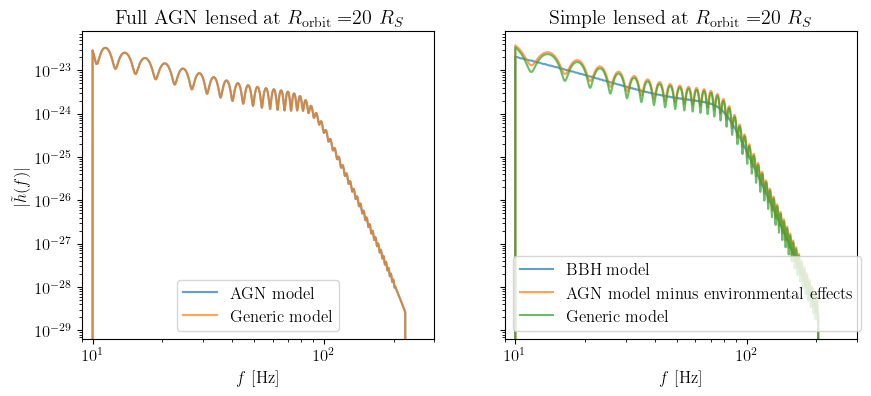

In [95]:
idx = 20

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

ax = axs[0]
ax.loglog(freq_array, np.abs(FD_AGN_strain[:, idx]), label='AGN model', alpha=0.7)
ax.loglog(freq_array, np.abs(FD_generic_AGN_strain[:, idx]), label='Generic model', alpha=0.7)
ax.set_xbound(9, 300)
ax.set_xlabel(r'$f$ [Hz]')
ax.set_ylabel(r'$|\tilde{h}(f)|$')
ax.set_title('Full AGN lensed at $R_{\mathrm{orbit}}=$%d $R_S$' % R_orbit_array[idx])
ax.legend()

ax = axs[1]
ax.loglog(freq_array, np.abs(FD_BBH_images_strain[:, idx]), label='BBH model', alpha=0.7)
ax.loglog(freq_array, np.abs(FD_no_AGN_strain[:, idx]), label='AGN model minus environmental effects', alpha=0.7)
ax.loglog(freq_array, np.abs(FD_generic_simple_strain[:, idx]), label='Generic model', alpha=0.7)
ax.set_xbound(9, 300)
ax.set_xlabel(r'$f$ [Hz]')
ax.set_title('Simple lensed at $R_{\mathrm{orbit}}=$%d $R_S$' % R_orbit_array[idx])
ax.legend()

The AGN lensed waveforms are the same but all three methods of generating simple lensing give different results! That's where the discrepancy comes from.

# Compute mismatch

## `Pycbc` mismatch ($MM$)

In [96]:
df = freq_array[1] - freq_array[0]
FS_psd = FrequencySeries(psd_interp, delta_f=df)

mismatch_samson_arr = np.zeros_like(R_orbit_array)
mismatch_ryan_1_arr = np.zeros_like(R_orbit_array)
mismatch_ryan_2_arr = np.zeros_like(R_orbit_array)

for i in range(len(R_orbit_array)):
    FS_generic_AGN_strain = FrequencySeries(FD_generic_AGN_strain[:, i], delta_f=df)
    FS_generic_simple_strain = FrequencySeries(FD_generic_simple_strain[:, i], delta_f=df)

    FS_AGN_strain = FrequencySeries(FD_AGN_strain[:, i], delta_f=df)
    FS_BBH_images_strain = FrequencySeries(FD_BBH_images_strain[:, i], delta_f=df)
    FS_no_AGN_strain = FrequencySeries(FD_no_AGN_strain[:, i], delta_f=df)

    match_samson, _ = match(FS_generic_AGN_strain, 
                        FS_generic_simple_strain, 
                        psd=FS_psd, 
                        low_frequency_cutoff=f_min)
    match_ryan_1, _ = match(FS_BBH_images_strain, 
                        FS_AGN_strain, 
                        psd=FS_psd, 
                        low_frequency_cutoff=f_min)
    match_ryan_2, _ = match(FS_no_AGN_strain, 
                        FS_AGN_strain, 
                        psd=FS_psd, 
                        low_frequency_cutoff=f_min)

    mismatch_samson_arr = mismatch_samson_arr.at[i].set(np.full_like(match_samson, 1) - match_samson)
    mismatch_ryan_1_arr = mismatch_ryan_1_arr.at[i].set(np.full_like(match_ryan_1, 1) - match_ryan_1)
    mismatch_ryan_2_arr = mismatch_ryan_2_arr.at[i].set(np.full_like(match_ryan_2, 1) - match_ryan_2)

## Alternative mismatch ($\overline{MM}$) for AGN lensing with no primary mass change

Mismatch (without maximizing over phase) between the following two waveforms:
- Full AGN lensed except chirp mass change is turned off, leaving only relative mass change and angular changes present
- Simple lensed

Both are generated with the `GeneralLensedGWSignal` model (Samson's method).

In [97]:
only_rel_mass_params = general_lensed_params.copy()
only_rel_mass_params['Mc'] = params['Mc']

FD_AGN_no_Mc_change_strain = cplx_zeros
FD_AGN_no_Mc_change_strain = FD_AGN_no_Mc_change_strain.at[freq_mask].set(
    L1_Lensed.GWstrain(masked_freq_grid, only_rel_mass_params)
    )
mismatch_no_Mc_change_arr = mismatch_alt(freq_grid, FD_AGN_no_Mc_change_strain, FD_generic_simple_strain, psd_interp_grid)

# Plot mismatch

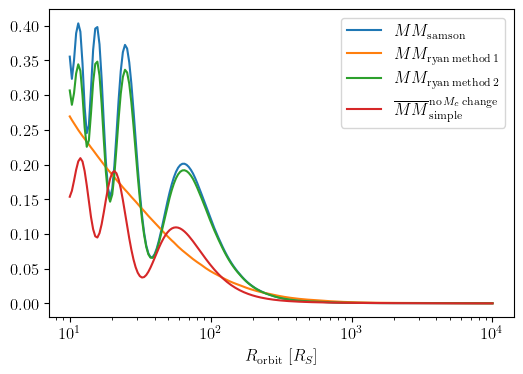

In [98]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(R_orbit_array, mismatch_samson_arr, label=r'$MM_{\mathrm{samson}}$')
ax.plot(R_orbit_array, mismatch_ryan_1_arr, label=r'$MM_{\mathrm{ryan\,method\,1}}$')
ax.plot(R_orbit_array, mismatch_ryan_2_arr, label=r'$MM_{\mathrm{ryan\,method\,2}}$')
ax.plot(R_orbit_array, mismatch_no_Mc_change_arr, label=r'$\overline{MM}^{\mathrm{no\,}M_c\mathrm{\,change}}_{\mathrm{simple}}$')
ax.set_xscale('log')
ax.set_xlabel(r'$R_{\mathrm{orbit}}$ [$R_S$]')
ax.legend()

The oscillations in $\overline{MM}$ don't match those in $MM$ :'(

## Test simple lensed parameters functions

In [28]:
def normal_lens_parameters(events):
    r_orbit = events['R_orbit']
    lens_mass = events['M_lz']
    luminosity_distance = events["dL"]
    y_src = events["src_pos"]
    d_LS = r_orbit * np.sqrt(1 - y_src**2)  # R_Sch
    _y_src = y_src * r_orbit  # R_Sch

    # Schwarschild radius
    # A small, but necessary assumption, that the lens is at dL
    z = np.interp(luminosity_distance, dLGridGlob, zGridGlob)
    lens_mass_src = lens_mass / (1 + z)
    print(f'{lens_mass_src = }')
    R_Sch = 2 * lens_mass_src * MRSUN_SI  # m
    delta = R_Sch / uGpc

    beta = _y_src / luminosity_distance * delta  # Radian
    print(f'{beta = }')
    ang_D_S = luminosity_distance

    ang_D_L = ang_D_S / (1 + d_LS * delta)  # Gpc
    theta_E = einstein_angle(lens_mass_src, ang_D_L, d_LS)  # Radian
    print(f'{theta_E = }')
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
    time_delay *= lens_mass_src * MTSUN_SI  

    print(time_delay)
    print(mag_1)
    print(mag_2)

    return time_delay, mag_1, mag_2

In [29]:
sub_params = {key: item[0] for key, item in params.items()}
time_delay, mag1, mag2 = normal_lens_parameters(sub_params)
print(np.sqrt(mag1), np.sqrt(mag2))

lens_mass_src = Array(8348.50140794, dtype=float64)
beta = Array(1.59804206e-18, dtype=float64)
theta_E = Array(3.53704851e-18, dtype=float64)
-0.14988073886050193
1.6896551825219053
0.6896551825219053
1.299867371127495 0.8304548046232891


In [17]:
pml_params = PML_simple_lens_parameters(sub_params)
pml_params['delta_time'] * DAY_TO_SEC, \
    sub_params['dL'] / pml_params['dL_1'], \
    sub_params['dL'] / pml_params['dL_2']

(Array(-0.14988074, dtype=float64),
 Array(1.29986737, dtype=float64),
 Array(0.8304548, dtype=float64))

In [ ]:
# theta_E, beta, lens_mass_src = 
get_agn_lens_angles(
    sub_params['M_lz'], sub_params['R_orbit'], 
    sub_params['src_pos'], sub_params['dL']
)

# So at least we got the source mass and beta agree

(Array(3.53704851e-18, dtype=float64),
 Array(1.59804206e-18, dtype=float64),
 Array(8348.50140794, dtype=float64))